# 📘 Task 2: Quantitative Analysis using PyNance and TA-Lib


Analyzing historical stock prices with technical indicators to understand market behavior.


Imports


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import talib
import yfinance as yf
import pynance as pn

In [ ]:
import sys
print(sys.executable)

c:\Program Files\Python313\python.exe


In [ ]:
df = pd.read_csv('../data/AAPL.csv')
df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


Clean & prepare the data


In [31]:

df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
df = df.astype(float)
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3774 entries, 2009-01-02 to 2023-12-29
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    3774 non-null   float64
 1   High    3774 non-null   float64
 2   Low     3774 non-null   float64
 3   Close   3774 non-null   float64
 4   Volume  3774 non-null   float64
dtypes: float64(5)
memory usage: 176.9 KB


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

 Date converted to datetime and set as index for time-series alignment



Clean & prepare the data


In [32]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)

if missing.any():
    df.dropna(inplace=True)
    print(f"\nDropped rows with nulls. Remaining rows: {len(df)}")
else:
    print("\nNo missing values found — dataset is clean.")

Missing values per column:
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

No missing values found — dataset is clean.


### Data Preparation
- Date converted to datetime and set as index for time-series alignment
- Only OHLCV columns retained; all cast to float64 as required by TA-Lib
- Missing value check: **no nulls found** — dataset is clean, no rows dropped

##  Technical Indicators (TA-Lib)

###  Moving Averages — SMA & EMA

In [ ]:
df['SMA_10'] = talib.SMA(df['Close'], 10)
df['SMA_20'] = talib.SMA(df['Close'], 20)
df['EMA_10'] = talib.EMA(df['Close'], 10)
df['EMA_20'] = talib.EMA(df['Close'], 20)

### 4.2 Relative Strength Index (RSI)

In [ ]:
df['RSI'] = talib.RSI(df['Close'], 14)

### MACD (Moving Average Convergence Divergence)

In [ ]:
df['MACD'], df['MACD_signal'], df['MACD_hist'] = talib.MACD(
    df['Close'], 12, 26, 9
)

## Financial Metrics 

In [ ]:
df['Returns'] = df['Close'].pct_change()
df['Volatility_20'] = df['Returns'].rolling(20).std()
df['Cumulative_Return'] = (1 + df['Returns']).cumprod()
df[['Returns', 'Volatility_20', 'Cumulative_Return']].head()

,Returns,Volatility_20,Cumulative_Return
Date,,,
2009-01-02,NaN,NaN,NaN
2009-01-05,0.042204,NaN,1.042204
2009-01-06,-0.016494,NaN,1.025014
2009-01-07,-0.021609,NaN,1.002865
2009-01-08,0.018570,NaN,1.021488


- **Returns:** Day-to-day % change in closing price. First row is NaN (no prior day to compare).
- **Volatility_20:** Rolling 20-day standard deviation of returns. NaN for the first 19 rows — needs 20 days of data. Higher values = more turbulent periods.
- **Cumulative_Return:** Tracks $1 invested on day one. By Jan 8, 2009 it had grown to ~$1.02 — minor early gains.

## Visualizations

### Price with Moving Averages

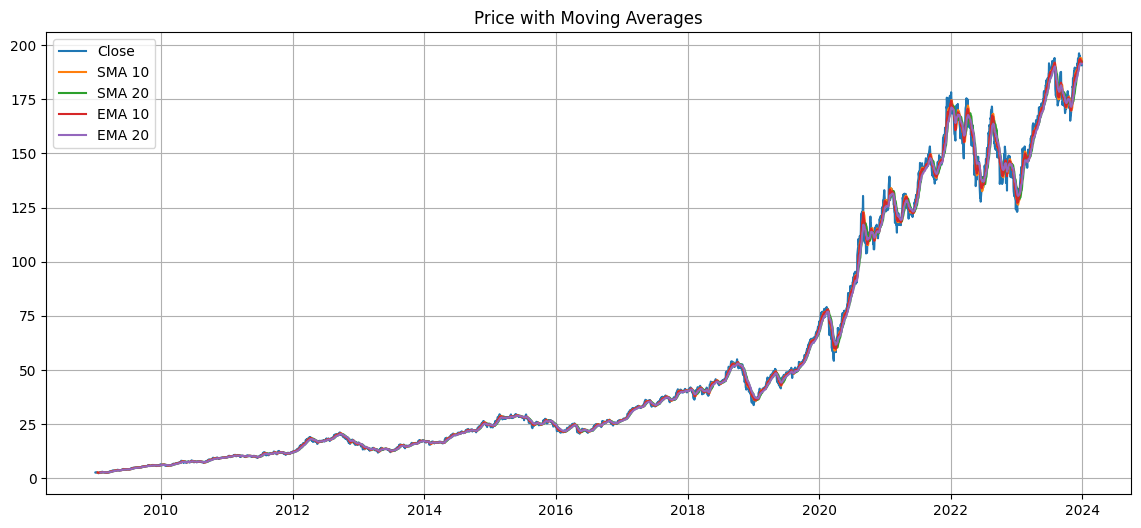

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Close'], label='Close')
plt.plot(df.index, df['SMA_10'], label='SMA 10')
plt.plot(df.index, df['SMA_20'], label='SMA 20')
plt.plot(df.index, df['EMA_10'], label='EMA 10')
plt.plot(df.index, df['EMA_20'], label='EMA 20')
plt.legend()
plt.title('Price with Moving Averages')
plt.grid()
plt.show()

### insight
Looking at it: all 5 lines (Close, SMA10, SMA20, EMA10, EMA20) are nearly identical and overlap completely — they're almost indistinguishable. This is actually meaningful to note. The price grew from ~$3 (2009) to ~$190 (2023). Major dip visible around 2020 (COVID crash) where price dropped to ~$55 before recovering. Another dip visible in 2022 down to ~$125. The lines are so close together because on a 15-year scale, 10 and 20-day differences are tiny.

### RSI Indicator (14-day)

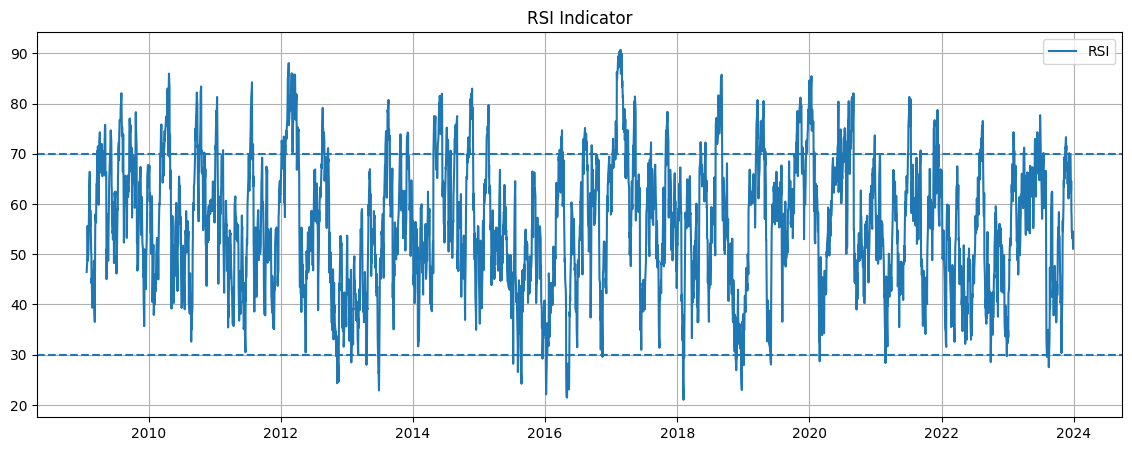

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['RSI'], label='RSI')
plt.axhline(70, linestyle='--')
plt.axhline(30, linestyle='--')
plt.legend()
plt.title('RSI Indicator')
plt.grid()
plt.show()

RSI crossed above **70 (overbought)** multiple times during AAPL's major rallies, particularly in 2019–2020 and late 2021 — signaling the market was pricing in excessive optimism. the lowest dips reach around 23-25 briefly in 2014 and again near 2020. It frequently spikes above 70 (overbought) — notably hitting ~88 in 2012 and ~90 in 2017. The 2020 COVID crash briefly pushed it below 30 before a sharp recovery.

### MACD Indicator (12, 26, 9)

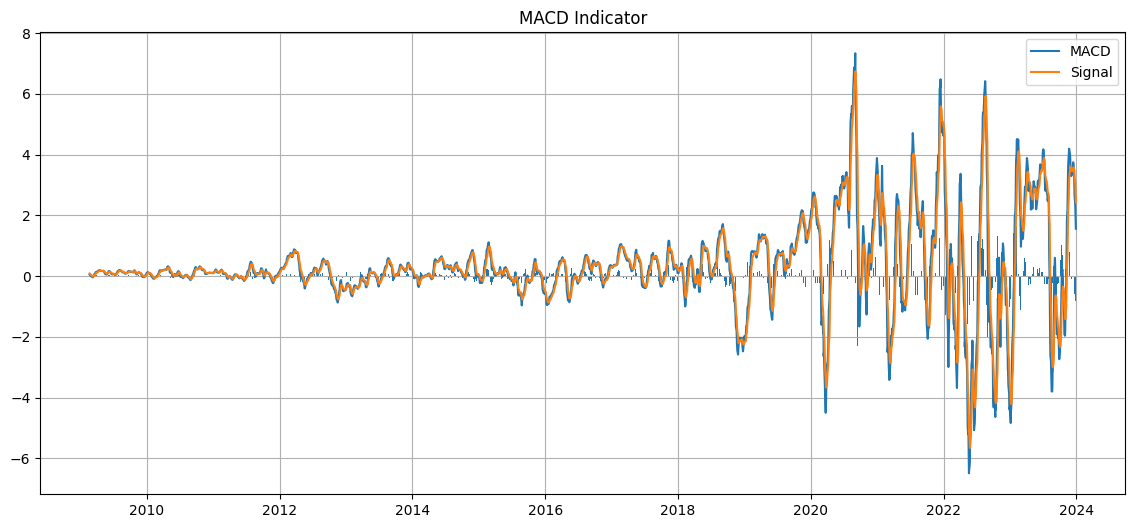

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['MACD'], label='MACD')
plt.plot(df.index, df['MACD_signal'], label='Signal')
plt.bar(df.index, df['MACD_hist'])
plt.legend()
plt.title('MACD Indicator')
plt.grid()
plt.show()

From 2009–2019, MACD values are very small (near zero) because prices were low. Post-2019, values expand dramatically as prices rose. The biggest positive spike (~7) was in early 2020 — the COVID recovery rally. The biggest negative dip (~-6.5) was in late 2022 — the broad market selloff. MACD and Signal lines track very closely — the histogram (bars) are barely visible at this scale.

In [ ]:
df.to_csv('../data/processed/AAPL_processed.csv')
print('Saved successfully')

Saved successfully
